### Spatial Gillespie implementation

This notebook runs a 2D lattice-based Gillespie simulation with local polymerization kinetics and diffusion between voxels.
- TODO: ggf bei Fragmentation keinen kompletten Zerfall zulassen?, @googlen bzgl Proteinaggregation mit spatialer Einbettung (Diffusionsterme & Proximität etc)!, speed that shit up!!!
- @wirklichen "Vortrag" planen etc! -> Bedeutung des Ganzen, wissenschaftliche Relevanz, ...
- local aggregation around focal point via slow nucleation + fast assoc/fragm + fast mono & slow poly diffusion!

In [367]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import tqdm

Mt = lambda f: np.tensordot(f[:, :, 1:], lengths, axes=([2], [0])).sum()
Pt = lambda f: f[:, :, 1:].sum()

# parameters: 1e1, 1e0, 1e3, 0, 1e2, 1e1, 3, 3 -> slow nucleation, fast aggregation and fragmentation, moderate secondary nucleation and coagulation
kn, kn2, ka, kd, kf, kc, nc, nc2 = 2e0, 1e0, 1e3, 0, 1e2, 1e1, 3, 3
Dm, Dp = 5e0, 5e-1  # monomer/polymer diffusion rates; ideally Dm = 5e0 (fast diffusion of monos) and Dp = 5e-1 (slow diffusion of polys)
max_steps, jmax, frames = int(3e3), 20, 100
nx, ny = 5, 5

# initial conditions
m0 = 1e2; m0_tot = m0 * nx * ny
m = np.full((nx, ny), m0, dtype=float) # homogeneous initial monomer distribution
# m = np.zeros((nx, ny), dtype=float); m[nx // 2, ny // 2] = m0_tot # all monomers in the center voxel to see spatial effects more clearly
f = np.zeros((nx, ny, jmax + 1), dtype=float)

lengths = np.arange(1, jmax + 1)
ftt, tt = [f.copy()], [0.0]
Mtt, Ptt, mtt = [Mt(f)], [Pt(f)], [m.copy()]

neigh_offsets = [(1, 0), (-1, 0), (0, 1), (0, -1)]
def neighbors(vx, vy):  # maybe periodic boundary conditions as alternative?
    for dx, dy in neigh_offsets:
        nxv, nyv = vx + dx, vy + dy
        if 0 <= nxv < nx and 0 <= nyv < ny: yield nxv, nyv  # non-periodic boundaries
        # yield nxv % nx, nyv % ny  # periodic boundaries

t, step = 0.0, 0
events = {'n1': 0, 'n2': 0, 'a': 0, 'd': 0, 'f': 0, 'c': 0, 'diff_m': 0, 'diff_p': 0}
event_locs = np.zeros((nx, ny), dtype=int) # for debugging: count events per voxel
voxel_rates, assoc, dissoc, fragm, nucl2 = np.zeros((nx, ny), dtype=float), np.zeros_like(f), np.zeros_like(f), np.zeros_like(f), np.zeros_like(f)
diff_m, diff_p = np.zeros((nx, ny), dtype=float), np.zeros((nx, ny, jmax + 1), dtype=float)

for s in tqdm.tqdm(range(max_steps)):
    # rates in each voxel
    for vx_ in range(nx):
        for vy_ in range(ny):
            fv = f[vx_, vy_]
            mt = m[vx_, vy_]
            nucl = kn * (mt / m0) ** nc # nucleation
            for j in range(nc, jmax): assoc[vx_, vy_, j] = ka * mt * fv[j] / (m0 ** 2)  # association
            for j in range(nc + 1, jmax + 1):   # dissociation / fragmentation
                dissoc[vx_, vy_, j] = kd * fv[j] / m0; fragm[vx_, vy_, j] = kf * fv[j] * (j - 1) / (m0 * jmax)
            for j in range(nc, jmax + 1): nucl2[vx_, vy_, j] = kn2 * (mt/m0)**nc2 * fv[j] * j / (m0 * jmax) # secondary nucleation
            coag_sum = 0.0
            for i in range(nc, jmax + 1):   # coagulation
                fi = fv[i]
                if fi <= 0: continue
                for j in range(i, jmax + 1):
                    fj = fv[j]
                    if fj <= 0 or i + j > jmax: continue
                    if i != j: coag_sum += kc * fi * fj / (m0 ** 2)
                    else: coag_sum += 0.5 * kc * fi * (fi - 1) / (m0 ** 2)
            # diffusion
            diff_m[vx_, vy_] = 0.0
            diff_p[vx_, vy_, :] = 0.0
            for nxv, nyv in neighbors(vx_, vy_):
                diff_m[vx_, vy_] += Dm * max(mt - m[nxv, nyv], 0.0) / m0  # only keep the "outward" rate to avoid double counting
                for j in range(1, jmax + 1):
                    dp_rate = Dp * max(fv[j] - f[nxv, nyv, j], 0.0) / m0
                    diff_p[vx_, vy_, j] += dp_rate
            # total
            voxel_rates[vx_, vy_] = nucl + assoc[vx_, vy_].sum() + dissoc[vx_, vy_].sum() + fragm[vx_, vy_].sum() + nucl2[vx_, vy_].sum() + coag_sum + diff_m[vx_, vy_] + diff_p[vx_, vy_].sum()

    total_rate = voxel_rates.sum()
    # print("step=", step, "voxel rates=", voxel_rates, "total_rate=", total_rate)
    if total_rate <= 0:
        print("total_rate=", total_rate)
        break

    rn1 = random.random()
    tau = -np.log(rn1) / total_rate
    rn2 = random.random() * total_rate

    # select voxel
    csum, vx, vy, found_voxel = 0.0, 0, 0, False
    for vx_ in range(nx):
        for vy_ in range(ny):
            csum += voxel_rates[vx_, vy_]
            if csum >= rn2:
                vx, vy = vx_, vy_
                found_voxel = True
                break
        if found_voxel: break
    if not found_voxel: vx, vy = nx - 1, ny - 1
    event_locs[vx, vy] += 1

    # determine event in the pixel
    loc_rate = voxel_rates[vx, vy]
    rv = rn2 - (csum - loc_rate)
    mt = m[vx, vy]
    fv = f[vx, vy]
    # print("selected voxel=", (vx, vy), "rv=", rv, "loc_rate=", loc_rate)
    cur = 0.0
    nucl_local = kn * (mt / m0) ** nc
    cur += nucl_local
    if rv <= cur:   # nucleation
        f[vx, vy, nc] += 1; events['n1'] += 1; m[vx, vy] -= nc
    else:
        done = False
        for jj in range(nc, jmax):  # assoiation
            cur += assoc[vx, vy, jj]
            if not done and rv <= cur:
                f[vx, vy, jj + 1] += 1; f[vx, vy, jj] -= 1
                done = True
                events['a'] += 1; m[vx, vy] -= 1
                break
        if not done:    # dissociation
            for jj in range(nc + 1, jmax + 1):
                cur += dissoc[vx, vy, jj]
                if not done and rv <= cur:
                    f[vx, vy, jj] -= 1; f[vx, vy, jj - 1] += 1
                    done = True
                    events['d'] += 1; m[vx, vy] += 1
                    break
        if not done:    # fragmentation -> here also with possibility of completely splitting into monomers
            for jj in range(nc + 1, jmax + 1):
                cur += fragm[vx, vy, jj]
                if not done and rv <= cur and f[vx, vy, jj] > 0:
                    f[vx, vy, jj] -= 1
                    events['f'] += 1
                    break_point = random.randint(1, jj - 1)
                    if break_point < nc:
                        if jj - break_point >= nc: f[vx, vy, jj - break_point] += 1; m[vx, vy] += break_point
                        else: m[vx, vy] += jj
                    elif break_point > jj - nc:
                        if break_point >= nc: f[vx, vy, break_point] += 1; m[vx, vy] += jj - break_point
                        else: m[vx, vy] += jj
                    else:
                        f[vx, vy, jj - break_point] += 1; f[vx, vy, break_point] += 1
                    done = True
                    break
        if not done:    # secondary nucleation
            for jj in range(nc, jmax + 1):
                cur += nucl2[vx, vy, jj]
                if not done and rv <= cur:
                    f[vx, vy, nc2] += 1; m[vx, vy] -= nc2
                    done = True
                    events['n2'] += 1
                    break
        if not done:    # coagulation
            for i in range(nc, jmax + 1):
                fi = fv[i]
                if fi <= 0: continue
                for j in range(i, jmax + 1):
                    fj = fv[j]
                    if fj <= 0 or i + j > jmax:
                        continue
                    rate_ij = kc * fi * fj / (m0 ** 2) if i != j else 0.5 * kc * fi * (fi - 1) / (m0 ** 2)
                    cur += rate_ij
                    if not done and rv <= cur:
                        f[vx, vy, i] -= 1; f[vx, vy, j] -= 1; f[vx, vy, i + j] += 1
                        done = True
                        events['c'] += 1
                        break
                if done: break
        if not done:    # monomer diffusion: pick neighbour weighted by the partial outward rates
            mt_local = m[vx, vy]
            for nxv, nyv in neighbors(vx, vy):
                rate_n = Dm * max(mt_local - m[nxv, nyv], 0.0) / m0
                cur += rate_n
                if rv <= cur and mt_local > 0:
                    m[vx, vy] -= 1.0
                    m[nxv, nyv] += 1.0
                    done = True
                    events['diff_m'] += 1
                    break
        if not done:    # polymer diffusion
            for jj in range(1, jmax + 1):
                cur += diff_p[vx, vy, jj]
                if rv <= cur and f[vx, vy, jj] > 0:
                    neighs = list(neighbors(vx, vy))
                    if neighs:
                        weights = [Dp * max(f[vx, vy, jj] - f[nxv, nyv, jj], 0.0) / m0 for nxv, nyv in neighs]
                        total_w = sum(weights)
                        if total_w > 0:
                            r = random.random() * total_w
                            for (nxv, nyv), w in zip(neighs, weights):
                                if r <= w:
                                    tx, ty = nxv, nyv
                                    break
                                r -= w
                            else: tx, ty = neighs[-1]
                            f[vx, vy, jj] -= 1.0
                            f[tx, ty, jj] += 1.0
                    events['diff_p'] += 1
                    done = True
                    break

    t += tau; step += 1

    if step % int(max_steps / frames) == 0:
        ftt.append(f.copy())
        tt.append(t)
        Mtt.append(np.tensordot(f[:, :, 1:], lengths, axes=([2], [0])).sum())
        Ptt.append(f[:, :, 1:].sum())
        mtt.append(m.copy())

Mtt, Ptt, tt, mtt = np.array(Mtt), np.array(Ptt), np.array(tt), np.array(mtt)
print("Finished spatial Gillespie: steps=", step, "diffusions=", events['diff_m'] + events['diff_p'], "reactions=", step - (events['diff_m'] + events['diff_p']), "time=", tt[-1], "snapshots=", len(ftt))
for i in events.keys():
    print(i + f': {events[i]}')
print("Event locations:\n", event_locs)

100%|██████████| 3000/3000 [00:20<00:00, 148.28it/s]

Finished spatial Gillespie: steps= 3000 diffusions= 162 reactions= 2838 time= 6.816817019918866 snapshots= 101
n1: 87
n2: 0
a: 2343
d: 0
f: 402
c: 6
diff_m: 150
diff_p: 12
Event locations:
 [[ 84 118 125 131 139]
 [ 93  99  87 163 105]
 [118 157 134 131 125]
 [134 129  93 137 118]
 [109 132 104 123 112]]


Text(0.5, 1.0, 'Total distribution at t=6.82')

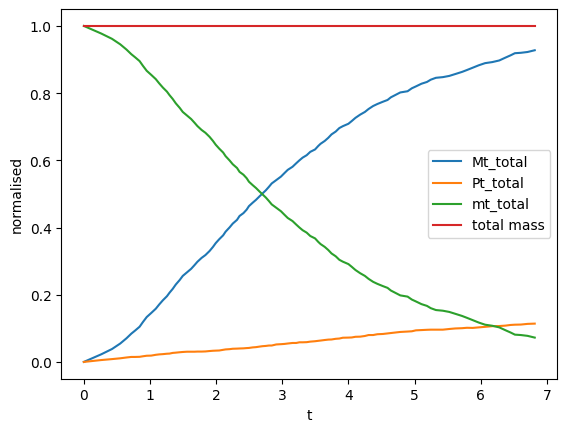

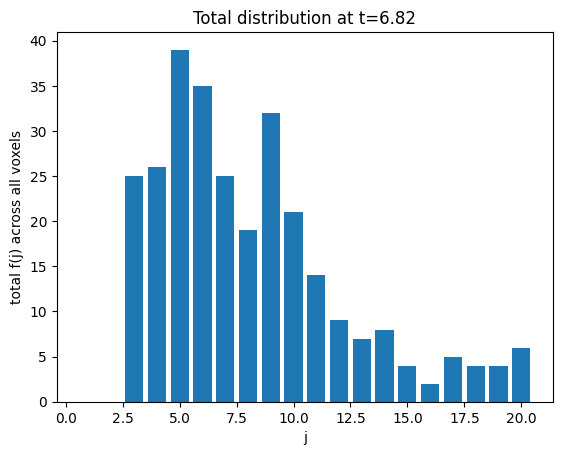

In [368]:
plt.figure()
monos = mtt.sum(axis=(1, 2))
plt.plot(tt, Mtt / m0_tot, label="Mt_total")
plt.plot(tt, Ptt / m0_tot, label="Pt_total")
plt.plot(tt, monos / m0_tot, label="mt_total")
plt.plot(tt, (Mtt + monos) / m0_tot, label="total mass")
plt.legend(); plt.xlabel("t"); plt.ylabel("normalised")

# plot total distribution across all voxels at final time
total_f = ftt[-1].sum(axis=(0, 1))
plt.figure()
plt.bar(lengths, total_f[1:])
plt.xlabel("j"); plt.ylabel("total f(j) across all voxels")
plt.title(f"Total distribution at t={tt[-1]:0.2f}")

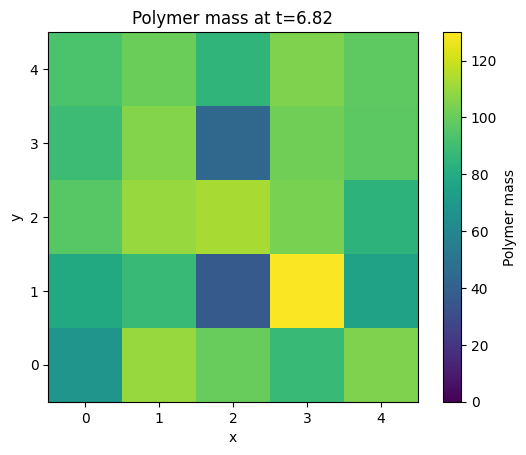

In [369]:
n_frames = min(len(ftt), frames)
indices = np.linspace(0, len(ftt) - 1, n_frames, dtype=int)
pol_mass = [np.tensordot(snap[:, :, 1:], lengths, axes=([2], [0])) for snap in ftt]
max_mass = max(arr.max() for arr in pol_mass)

fig, ax = plt.subplots()
im = ax.imshow(pol_mass[0], origin='lower', cmap='viridis', vmin=0, vmax=max_mass)
cbar = fig.colorbar(im, ax=ax, label='Polymer mass')
ax.set_xlabel('x'); ax.set_ylabel('y')
title = ax.set_title(f'Polymer mass at t={tt[indices[0]]:.2f}')

def update(frame_idx):
    idx = indices[frame_idx]
    im.set_array(pol_mass[frame_idx])
    title.set_text(f'Polymer mass at t={tt[idx]:.2f}')
    return [im, title]

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=100, blit=True)
anim.save('polymer_mass.gif', writer='pillow')

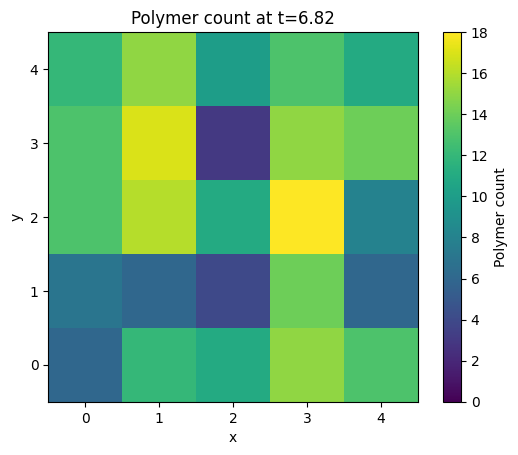

In [370]:
pol_count = [snap[:, :, 1:].sum(axis=2) for snap in ftt]
max_count = max(arr.max() for arr in pol_count)

fig, ax = plt.subplots()
im = ax.imshow(pol_count[0], origin='lower', cmap='viridis', vmin=0, vmax=max_count)
cbar = fig.colorbar(im, ax=ax, label='Polymer count')
ax.set_xlabel('x'); ax.set_ylabel('y')
title = ax.set_title(f'Polymer mass at t={tt[indices[0]]:.2f}')

def update(frame_idx):
    idx = indices[frame_idx]
    im.set_array(pol_count[frame_idx])
    title.set_text(f'Polymer count at t={tt[idx]:.2f}')
    return [im, title]

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=100, blit=True)
anim.save('polymer_count.gif', writer='pillow')

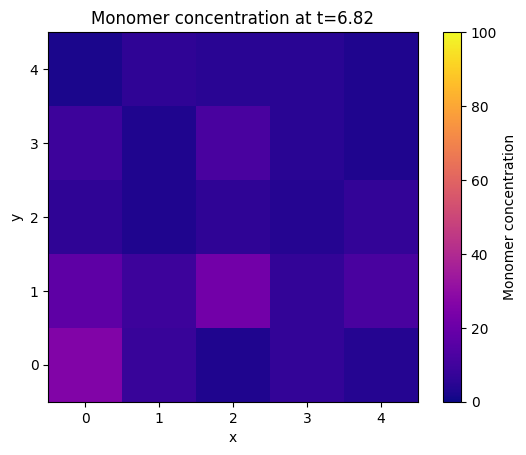

In [371]:
# also do for monomer concentration, adding colorbar for better visibility
monomer_series = [snap.copy() for snap in mtt]
vmax_m = max(arr.max() for arr in monomer_series)
fig, ax = plt.subplots()
im = ax.imshow(mtt[0], origin='lower', cmap='plasma', vmin=0, vmax=vmax_m)
cbar = fig.colorbar(im, ax=ax, label='Monomer concentration')
ax.set_xlabel('x')
ax.set_ylabel('y')
title = ax.set_title(f'Monomer concentration at t={tt[0]:.2f}')
def update_monomer(frame_idx):
    idx = indices[frame_idx]
    im.set_array(mtt[frame_idx])
    title.set_text(f'Monomer concentration at t={tt[idx]:.2f}')
    return [im, title]
anim_m = animation.FuncAnimation(fig, update_monomer, frames=n_frames, interval=100, blit=True)
anim_m.save('monomer_concentration.gif', writer='pillow')